In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import img_tiles
from matplotlib.patches import Rectangle

from metpy.plots import USCOUNTIES

In [41]:
def build_test_map(
    fig,
    extent=(-122, -73, 21, 56),
    rect=(0.02, 0.04, 0.86, 0.84),
    projection=None,
    terrain=True,
    terrain_alpha=0.40,
    terrain_zoom=4,
    counties=False,
):
    """
    Add a styled Cartopy map to an existing figure.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Existing figure.

    extent : sequence
        [west, east, south, north].

    rect : tuple
        Figure-relative [left, bottom, width, height] for the map axes.

    projection : cartopy.crs
        Map projection. If None, a Lambert Conformal projection centered
        on the requested extent is created.

    terrain : bool
        Add shaded-relief imagery.

    terrain_alpha : float
        Terrain opacity.

    terrain_zoom : int
        Tile zoom level.

    counties : bool
        Add county boundaries.

    Returns
    -------
    ax : cartopy.mpl.geoaxes.GeoAxes
    """

    west, east, south, north = extent

    # ------------------------------------------------------------------
    # Projection
    # ------------------------------------------------------------------

    if projection is None:
        projection = ccrs.LambertConformal(
            central_longitude=(west + east) / 2,
            central_latitude=(south + north) / 2,
            standard_parallels=(30, 60),
        )

    # ------------------------------------------------------------------
    # Create map axes in an EXACT figure location
    # ------------------------------------------------------------------

    ax = fig.add_axes(
        rect,
        projection=projection,
    )

    ax.set_extent(
        extent,
        crs=ccrs.PlateCarree(),
    )

    # ------------------------------------------------------------------
    # Signature basemap colors
    # ------------------------------------------------------------------

    land_color = "#1A2229"
    water_color = "#071018"

    state_color = "#AAB4BC"
    border_color = "#C6CDD2"
    county_color = "#65727C"

    ax.set_facecolor(water_color)

    ax.add_feature(
        cfeature.LAND.with_scale("50m"),
        facecolor=land_color,
        edgecolor="none",
        zorder=0,
    )

    ax.add_feature(
        cfeature.OCEAN.with_scale("50m"),
        facecolor=water_color,
        edgecolor="none",
        zorder=0,
    )

    ax.add_feature(
        cfeature.LAKES.with_scale("50m"),
        facecolor=water_color,
        edgecolor="none",
        zorder=0.1,
    )

    # ------------------------------------------------------------------
    # Shaded terrain
    # ------------------------------------------------------------------

    if terrain:

        terrain_tiles = img_tiles.GoogleTiles(
            url=(
                "https://server.arcgisonline.com/ArcGIS/rest/services/"
                "World_Shaded_Relief/MapServer/tile/{z}/{y}/{x}.jpg"
            ),
            cache=True,
        )

        ax.add_image(
            terrain_tiles,
            terrain_zoom,
            alpha=terrain_alpha,
            zorder=0.25,
        )

    # ------------------------------------------------------------------
    # Geographic boundaries
    # ------------------------------------------------------------------

    ax.add_feature(
        cfeature.STATES.with_scale("50m"),
        facecolor="none",
        edgecolor=state_color,
        linewidth=1.1,
        alpha=0.80,
        zorder=10,
    )

    ax.add_feature(
        cfeature.BORDERS.with_scale("50m"),
        facecolor="none",
        edgecolor=border_color,
        linewidth=1.15,
        alpha=0.90,
        zorder=10.1,
    )

    ax.add_feature(
        cfeature.COASTLINE.with_scale("50m"),
        facecolor="none",
        edgecolor=border_color,
        linewidth=1.15,
        alpha=0.90,
        zorder=10.2,
    )

    if counties:
        ax.add_feature(
            USCOUNTIES.with_scale("20m"),
            facecolor="none",
            edgecolor=county_color,
            linewidth=0.40,
            alpha=0.30,
            zorder=9,
        )

    # ------------------------------------------------------------------
    # Remove normal Cartopy frame
    # ------------------------------------------------------------------

    try:
        ax.spines["geo"].set_visible(False)
    except Exception:
        pass

    return ax

In [58]:
def build_test_figure(
    extent=(-122, -73, 21, 56),

    # Header
    title="GFS • 500 hPa Forecast",
    subtitle="Geopotential Height • Relative Vorticity • Wind",
    valid="VALID • F024 • FRI 11 SEP 2026 • 18Z",

    # Footer
    footer_left="GFS 0.25° • INIT 11 SEP 2026 12Z",
    footer_right="UND Atmospheric Sciences • Weather Wall",

    # Branding
    logo_path=None,

    # Figure
    figsize=(20, 10),
    dpi=150,

    # Map
    terrain=True,
    terrain_alpha=0.35,
    terrain_zoom=4,
    counties=False,
):
    """
    Old-style Weather Wall layout:
    - full UND green figure background
    - large map area
    - header on green band
    - colorbar in right green rail
    - tiny footer
    """

    # ========================================================
    # FIGURE
    # ========================================================

    fig = plt.figure(
        figsize=figsize,
        dpi=dpi,
        facecolor=UND_GREEN,
    )

    # ========================================================
    # LAYOUT
    #
    # Tuned to resemble the older layout more closely.
    # ========================================================

    MAP_RECT = [
        0.020,   # left
        0.055,   # bottom
        0.860,   # width
        0.825,   # height
    ]

    HEADER_RECT = [
        0.015,
        0.900,
        0.700,
        0.080,
    ]

    LOGO_RECT = [
        0.775,
        0.905,
        0.105,
        0.070,
    ]

    COLORBAR_RECT = [
        0.905,
        0.165,
        0.014,
        0.600,
    ]

    FOOTER_RECT = [
        0.015,
        0.006,
        0.970,
        0.022,
    ]

    # ========================================================
    # MAP
    # ========================================================

    ax = build_test_map(
        fig,
        extent=extent,
        rect=MAP_RECT,
        terrain=terrain,
        terrain_alpha=terrain_alpha,
        terrain_zoom=terrain_zoom,
        counties=counties,
    )

    # ========================================================
    # HEADER
    # ========================================================

    header_ax = fig.add_axes(HEADER_RECT, facecolor="none")
    header_ax.set_xlim(0, 1)
    header_ax.set_ylim(0, 1)
    header_ax.axis("off")

    header_ax.text(
        0.0,
        0.72,
        title,
        ha="left",
        va="center",
        fontsize=21,
        fontweight="bold",
        color=TEXT_PRIMARY,
    )

    header_ax.text(
        0.0,
        0.33,
        subtitle,
        ha="left",
        va="center",
        fontsize=12.8,
        fontweight="medium",
        color=TEXT_SECONDARY,
    )

    header_ax.text(
        0.0,
        0.00,
        valid,
        ha="left",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color=TEXT_VALID,
    )

    # thin underline accent like the older layout
    header_ax.plot(
        [0.0, 0.18],
        [-0.02, -0.02],
        color="#18C3BF",
        linewidth=2.0,
        solid_capstyle="round",
        clip_on=False,
    )

    # ========================================================
    # LOGO
    # ========================================================

    logo_ax = fig.add_axes(LOGO_RECT, facecolor="none")
    logo_ax.set_xlim(0, 1)
    logo_ax.set_ylim(0, 1)
    logo_ax.axis("off")

    if logo_path is not None:
        logo_path = Path(logo_path)
        if logo_path.exists():
            logo = plt.imread(logo_path)
            logo_ax.imshow(logo, aspect="contain")
    else:
        # placeholder
        logo_ax.text(
            1.0,
            0.72,
            "UND",
            ha="right",
            va="center",
            fontsize=22,
            fontweight="heavy",
            color=TEXT_PRIMARY,
        )
        logo_ax.text(
            1.0,
            0.22,
            "ATMOSPHERIC SCIENCES",
            ha="right",
            va="center",
            fontsize=8.2,
            fontweight="bold",
            color=TEXT_SECONDARY,
        )

    # ========================================================
    # COLORBAR SLOT
    # ========================================================

    cbar_ax = fig.add_axes(COLORBAR_RECT, facecolor="none")
    cbar_ax.set_axis_off()

    # ========================================================
    # FOOTER
    # ========================================================

    footer_ax = fig.add_axes(FOOTER_RECT, facecolor="none")
    footer_ax.set_xlim(0, 1)
    footer_ax.set_ylim(0, 1)
    footer_ax.axis("off")

    footer_ax.text(
        0.0,
        0.15,
        footer_left,
        ha="left",
        va="bottom",
        fontsize=7.2,
        fontweight="medium",
        color=TEXT_MUTED,
    )

    footer_ax.text(
        1.0,
        0.15,
        footer_right,
        ha="right",
        va="bottom",
        fontsize=7.2,
        fontweight="medium",
        color=TEXT_MUTED,
    )

    slots = {
        "header": header_ax,
        "logo": logo_ax,
        "colorbar": cbar_ax,
        "footer": footer_ax,
    }

    return fig, ax, slots

Text(0.5, 1.0, 'WIND\nkt')

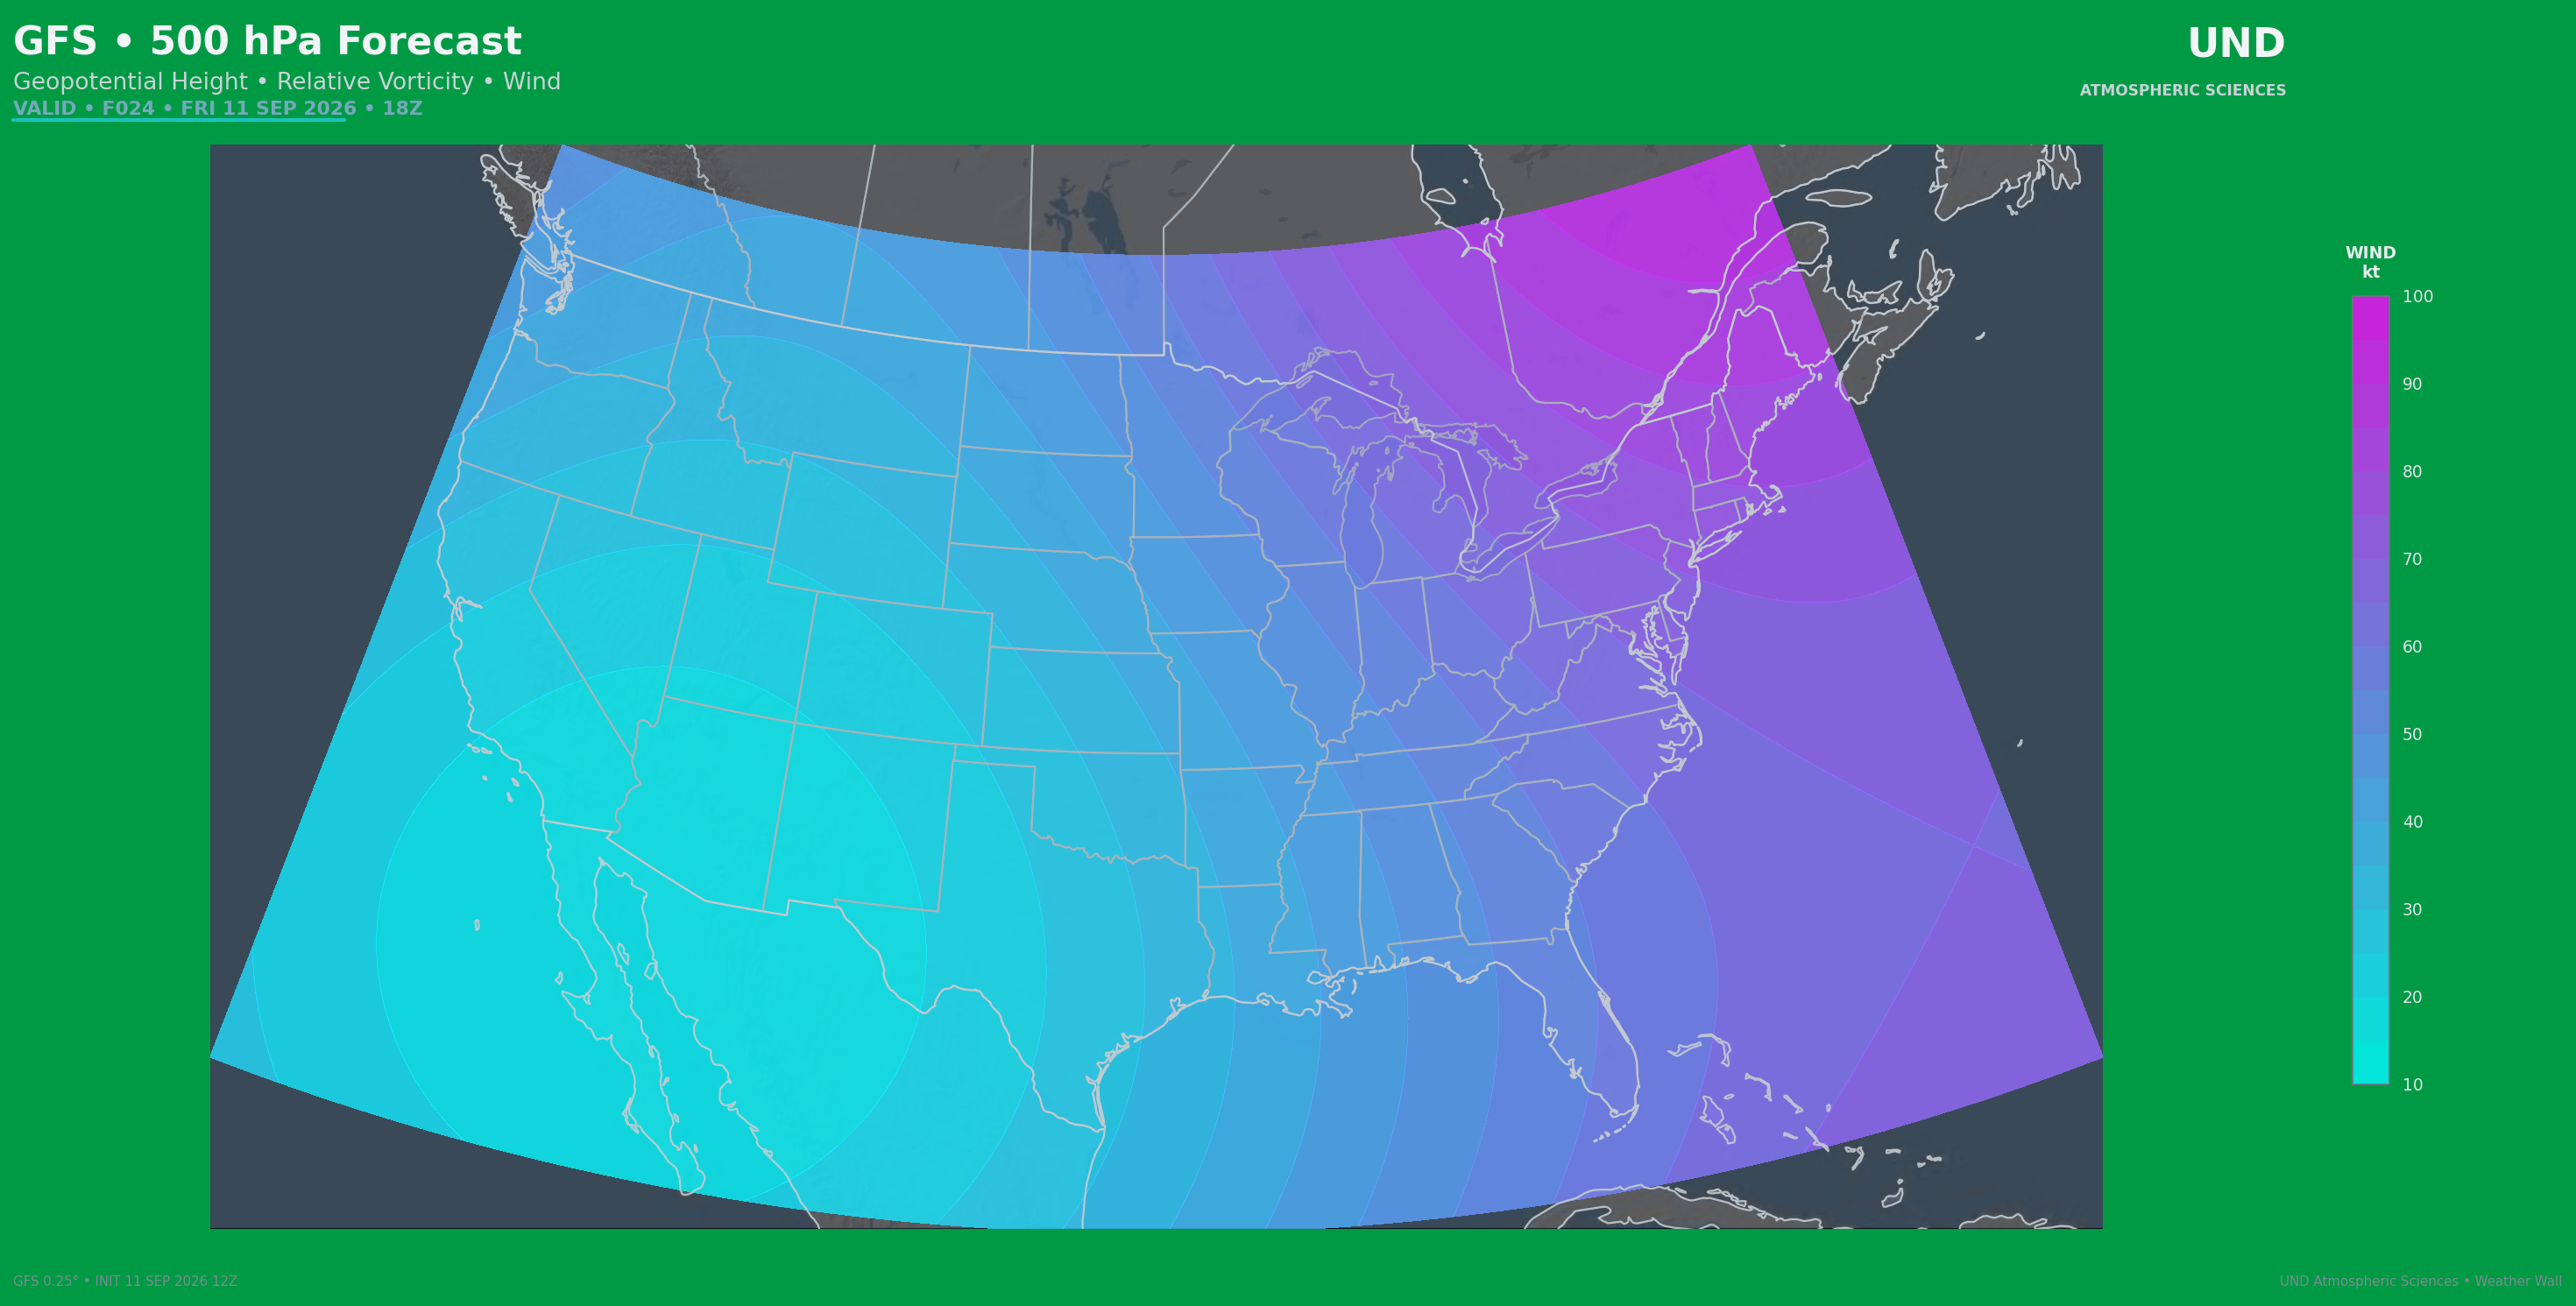

In [59]:
import numpy as np
import matplotlib.colors as mcolors

lon = np.linspace(-125, -66, 300)
lat = np.linspace(23, 52, 180)

LON, LAT = np.meshgrid(lon, lat)

field = (
    50
    + 25 * np.sin(np.deg2rad(LON * 4))
    + 15 * np.cos(np.deg2rad(LAT * 6))
)


fig, ax, slots = build_test_figure(
    extent=[-125, -66, 23, 52],
    title="GFS • 500 hPa Forecast",
    subtitle="Geopotential Height • Relative Vorticity • Wind",
    valid="VALID • F024 • FRI 11 SEP 2026 • 18Z",
    terrain=True,
)


cf = ax.contourf(
    LON,
    LAT,
    field,
    levels=np.arange(10, 101, 5),
    cmap="cool",
    transform=ccrs.PlateCarree(),
    alpha=0.80,
    zorder=2,
)

# Re-enable the reserved colorbar axes
slots["colorbar"].set_axis_on()

cbar = fig.colorbar(
    cf,
    cax=slots["colorbar"],
    orientation="vertical",
)

cbar.ax.tick_params(
    labelsize=9,
    colors="#DDE5E9",
    width=0,
)

cbar.outline.set_edgecolor("#6B7880")
cbar.outline.set_linewidth(0.8)

cbar.ax.set_title(
    "WIND\nkt",
    fontsize=9,
    fontweight="bold",
    color="#E8EEF1",
    pad=10,
)
